# Join và tính toán các metrics

In [37]:
from pathlib import Path
import pandas as pd, json

def read_folder(path="data/cleaned"):
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"{path} does not exist")
    files = sorted([f for f in p.iterdir() if f.is_file()])
    out = {}

    for f in files:
        suf = f.suffix.lower()
        if suf in (".csv", ".tsv"):
            sep = "\t" if suf == ".tsv" else ","
            out[f.name] = pd.read_csv(f, sep=sep)
        elif suf in (".parquet",):
            out[f.name] = pd.read_parquet(f)
        elif suf == ".json":
            try:
                out[f.name] = pd.read_json(f, lines=True)
            except ValueError:
                with f.open("r", encoding="utf8") as fh:
                    out[f.name] = json.load(fh)
        elif suf == ".txt":
            out[f.name] = f.read_text(encoding="utf8")
        else:
            out[f.name] = f.read_bytes()

    print(f"Read {len(out)} files from {path}: {', '.join(out.keys())}")
    return out

# Example usage:
# data = read_folder("data/cleaned")

In [38]:
folder = Path("data/cleaned")
csv_files = sorted(folder.glob("*.csv"))[:6]

if len(csv_files) < 6:
    raise FileNotFoundError(f"Found only {len(csv_files)} CSV files in {folder}")

data = {f.name: pd.read_csv(f) for f in csv_files}
print("Read CSV files:", list(data.keys()))

Read CSV files: ['cleaned_customers.csv', 'cleaned_items.csv', 'cleaned_orders.csv', 'cleaned_payments.csv', 'cleaned_products.csv', 'cleaned_sellers.csv']


In [39]:
df_customers = data['cleaned_customers.csv']
df_items = data['cleaned_items.csv']
df_orders = data['cleaned_orders.csv']
df_payments = data['cleaned_payments.csv']
df_products = data['cleaned_products.csv']

In [40]:
df_customers

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [41]:
df_items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [42]:
df_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


In [43]:
df_payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [44]:
df_products

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [45]:
df_customers

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [46]:
df_merge = df_customers.merge(df_orders, on='customer_id', how='left')

In [47]:
df_merge

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15
...,...,...,...,...,...,...,...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05


In [48]:
# Tạo dataset mới gồm customer_unique_id và frequency
olist_customers = (
    df_merge.groupby('customer_unique_id')
      .size()
      .reset_index(name='frequency')
)

# Xem kết quả
olist_customers

,customer_unique_id,frequency
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1
...,...,...
96091,fffcf5a5ff07b0908bd4e2dbc735a684,1
96092,fffea47cd6d3cc0a88bd621562a9d061,1
96093,ffff371b4d645b6ecea244b27531430a,1
96094,ffff5962728ec6157033ef9805bacc48,1


In [49]:
olist_customers['frequency'].value_counts()

frequency
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

In [50]:
# Chuyển order_purchase_timestamp sang datetime
df_merge['order_purchase_timestamp'] = pd.to_datetime(
    df_merge['order_purchase_timestamp']
)

# Lấy ngày snapshot (ngày lớn nhất + 1)
snapshot_date = (
    df_merge['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
)

# Tạo dataset gồm frequency và recency
olist_customers = (
    df_merge.groupby('customer_unique_id')
    .agg(
        frequency=('order_id', 'count'),
        last_purchase=('order_purchase_timestamp', 'max')
    )
    .reset_index()
)

# Tính recency = số ngày từ lần mua cuối đến snapshot_date
olist_customers['recency'] = (
    snapshot_date - olist_customers['last_purchase']
).dt.days

# Xóa cột last_purchase nếu không cần
olist_customers = olist_customers.drop(columns='last_purchase')

# Xem kết quả
olist_customers

,customer_unique_id,frequency,recency
0,0000366f3b9a7992bf8c76cfdf3221e2,1,161
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,164
2,0000f46a3911fa3c0805444483337064,1,586
3,0000f6ccb0745a6a4b88665a16c9f078,1,370
4,0004aac84e0df4da2b147fca70cf8255,1,337
...,...,...,...
96091,fffcf5a5ff07b0908bd4e2dbc735a684,1,496
96092,fffea47cd6d3cc0a88bd621562a9d061,1,311
96093,ffff371b4d645b6ecea244b27531430a,1,618
96094,ffff5962728ec6157033ef9805bacc48,1,169


In [51]:
# Join df_merge với df_payments theo order_id
df_merge = df_merge.merge(
    df_payments,
    on='order_id',
    how='left'
)

# Xem kết quả
df_merge

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,1.0,credit_card,2.0,146.87
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,1.0,credit_card,8.0,335.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,1.0,credit_card,7.0,157.73
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,1.0,credit_card,1.0,173.30
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,1.0,credit_card,8.0,252.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103882,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25,1.0,credit_card,6.0,88.78
103883,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20,1.0,credit_card,3.0,129.06
103884,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02,1.0,credit_card,5.0,56.04
103885,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05,1.0,credit_card,2.0,711.07


In [52]:
# Chuyển timestamp sang datetime
df_merge['order_purchase_timestamp'] = pd.to_datetime(
    df_merge['order_purchase_timestamp']
)

# Snapshot date
snapshot_date = (
    df_merge['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
)

# Tạo RFM dataframe
olist_customers = (
    df_merge.groupby('customer_unique_id')
    .agg(
        frequency=('order_id', 'count'),
        monetary=('payment_value', 'sum'),
        last_purchase=('order_purchase_timestamp', 'max')
    )
    .reset_index()
)

# Tính recency
olist_customers['recency'] = (
    snapshot_date - olist_customers['last_purchase']
).dt.days

# Sắp xếp lại cột
olist_customers = olist_customers[
    ['customer_unique_id', 'recency', 'frequency', 'monetary']
]

# Xem kết quả
olist_customers

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
2,0000f46a3911fa3c0805444483337064,586,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89
...,...,...,...,...
96091,fffcf5a5ff07b0908bd4e2dbc735a684,496,1,2067.42
96092,fffea47cd6d3cc0a88bd621562a9d061,311,1,84.58
96093,ffff371b4d645b6ecea244b27531430a,618,1,112.46
96094,ffff5962728ec6157033ef9805bacc48,169,1,133.69


In [53]:
# Thêm avg_order_value vào olist_customers
olist_customers['avg_order_value'] = (
    olist_customers['monetary'] / olist_customers['frequency']
)

# Xem kết quả
olist_customers

,customer_unique_id,recency,frequency,monetary,avg_order_value
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,27.19
2,0000f46a3911fa3c0805444483337064,586,1,86.22,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,43.62
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,196.89
...,...,...,...,...,...
96091,fffcf5a5ff07b0908bd4e2dbc735a684,496,1,2067.42,2067.42
96092,fffea47cd6d3cc0a88bd621562a9d061,311,1,84.58,84.58
96093,ffff371b4d645b6ecea244b27531430a,618,1,112.46,112.46
96094,ffff5962728ec6157033ef9805bacc48,169,1,133.69,133.69


In [54]:
# Join df_merge với df_items theo order_id
df_merge = df_merge.merge(
    df_items,
    on='order_id',
    how='left'
)

# Xem kết quả
df_merge

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,1.0,credit_card,2.0,146.87,1.0,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,1.0,credit_card,8.0,335.48,1.0,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,1.0,credit_card,7.0,157.73,1.0,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,1.0,credit_card,1.0,173.30,1.0,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,1.0,credit_card,8.0,252.25,1.0,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118429,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25,1.0,credit_card,6.0,88.78,1.0,ccb4503d9d43d245d3b295d0544f988b,527801b552d0077ffd170872eb49683b,2018-04-12 16:08:45,74.90,13.88
118430,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20,1.0,credit_card,3.0,129.06,1.0,9ede6b0570a75a4b9de4f383329f99ee,3fd1e727ba94cfe122d165e176ce7967,2018-04-10 08:35:12,114.90,14.16
118431,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02,1.0,credit_card,5.0,56.04,1.0,7a5d2e1e131a860ae7d18f6fffa9d689,d9e7e7778b32987280a6f2cb9a39c57d,2018-04-12 20:30:03,37.00,19.04
118432,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05,1.0,credit_card,2.0,711.07,1.0,f819f0c84a64f02d3a5606ca95edd272,4869f7a5dfa277a7dca6462dcf3b52b2,2017-11-09 21:15:51,689.00,22.07


In [55]:
# Tính total_items cho mỗi customer
total_items = (
    df_merge.groupby('customer_unique_id')['order_item_id']
    .count()
    .reset_index(name='total_items')
)

# Merge vào olist_customers
olist_customers = olist_customers.merge(
    total_items,
    on='customer_unique_id',
    how='left'
)

# Xem kết quả
olist_customers

,customer_unique_id,recency,frequency,monetary,avg_order_value,total_items
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,141.90,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,27.19,1
2,0000f46a3911fa3c0805444483337064,586,1,86.22,86.22,1
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,43.62,1
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,196.89,1
...,...,...,...,...,...,...
96091,fffcf5a5ff07b0908bd4e2dbc735a684,496,1,2067.42,2067.42,2
96092,fffea47cd6d3cc0a88bd621562a9d061,311,1,84.58,84.58,1
96093,ffff371b4d645b6ecea244b27531430a,618,1,112.46,112.46,1
96094,ffff5962728ec6157033ef9805bacc48,169,1,133.69,133.69,1


In [56]:
import pandas as pd

# Cài đặt hiển thị full cột
pd.set_option('display.max_columns', None)      # Hiển thị tất cả các cột
pd.set_option('display.max_colwidth', None)     # Hiển thị full nội dung từng ô
pd.set_option('display.width', None)            # Không ngắt dòng
pd.set_option('display.expand_frame_repr', False)  # Không xuống dòng khi in DataFrame

In [57]:
# Join df_merge với df_items theo order_id
df_merge = df_merge.merge(
    df_products,
    on='product_id',
    how='left'
)

# Xem kết quả
df_merge

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,1.0,credit_card,2.0,146.87,1.0,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88,moveis_escritorio,41.0,1141.0,1.0,8683.0,54.0,64.0,31.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,1.0,credit_card,8.0,335.48,1.0,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48,utilidades_domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,1.0,credit_card,7.0,157.73,1.0,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79,moveis_escritorio,55.0,955.0,1.0,8267.0,52.0,52.0,17.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,1.0,credit_card,1.0,173.30,1.0,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36,moveis_escritorio,48.0,1066.0,1.0,12160.0,56.0,51.0,28.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,1.0,credit_card,8.0,252.25,1.0,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25,casa_conforto,61.0,407.0,1.0,5200.0,45.0,15.0,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118429,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25,1.0,credit_card,6.0,88.78,1.0,ccb4503d9d43d245d3b295d0544f988b,527801b552d0077ffd170872eb49683b,2018-04-12 16:08:45,74.90,13.88,livros_interesse_geral,51.0,489.0,2.0,611.0,22.0,22.0,23.0
118430,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20,1.0,credit_card,3.0,129.06,1.0,9ede6b0570a75a4b9de4f383329f99ee,3fd1e727ba94cfe122d165e176ce7967,2018-04-10 08:35:12,114.90,14.16,esporte_lazer,51.0,1193.0,1.0,1211.0,25.0,24.0,22.0
118431,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02,1.0,credit_card,5.0,56.04,1.0,7a5d2e1e131a860ae7d18f6fffa9d689,d9e7e7778b32987280a6f2cb9a39c57d,2018-04-12 20:30:03,37.00,19.04,beleza_saude,60.0,575.0,1.0,870.0,25.0,20.0,18.0
118432,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea

In [58]:
# Tính số lượng sản phẩm unique mà mỗi customer đã mua
unique_products = (
    df_merge.groupby('customer_unique_id')['product_id']
    .nunique()
    .reset_index(name='unique_products')
)

# Merge vào olist_customers
olist_customers = olist_customers.merge(
    unique_products,
    on='customer_unique_id',
    how='left'
)

# Xem kết quả
olist_customers.head()

,customer_unique_id,recency,frequency,monetary,avg_order_value,total_items,unique_products
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,141.90,1,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,27.19,1,1
2,0000f46a3911fa3c0805444483337064,586,1,86.22,86.22,1,1
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,43.62,1,1
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,196.89,1,1


In [59]:
# Tính số lượng category khác nhau mà mỗi customer đã mua
unique_categories = (
    df_merge.groupby('customer_unique_id')['product_category_name']
    .nunique()
    .reset_index(name='unique_categories')
)

# Merge vào olist_customers
olist_customers = olist_customers.merge(
    unique_categories,
    on='customer_unique_id',
    how='left'
)

# Xem kết quả
olist_customers.head()

,customer_unique_id,recency,frequency,monetary,avg_order_value,total_items,unique_products,unique_categories
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,141.90,1,1,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,27.19,1,1,1
2,0000f46a3911fa3c0805444483337064,586,1,86.22,86.22,1,1,1
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,43.62,1,1,1
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,196.89,1,1,1


In [60]:
# Tính avg_installments cho mỗi customer
avg_installments = (
    df_merge.groupby('customer_unique_id')['payment_installments']
    .mean()
    .reset_index(name='avg_installments')
)

# Merge vào olist_customers
olist_customers = olist_customers.merge(
    avg_installments,
    on='customer_unique_id',
    how='left'
)

# Làm tròn nếu muốn
olist_customers['avg_installments'] = (
    olist_customers['avg_installments'].round(2)
)

# Xem kết quả
olist_customers.head()

,customer_unique_id,recency,frequency,monetary,avg_order_value,total_items,unique_products,unique_categories,avg_installments
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,141.90,1,1,1,8.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,27.19,1,1,1,1.0
2,0000f46a3911fa3c0805444483337064,586,1,86.22,86.22,1,1,1,8.0
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,43.62,1,1,1,4.0
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,196.89,1,1,1,6.0


In [61]:
df_merge['payment_type'].value_counts()

payment_type
credit_card    87286
boleto         23037
voucher         6407
debit_card      1698
not_defined        3
Name: count, dtype: int64

In [62]:
# Tính tỷ lệ (%) từng payment_type cho mỗi customer

payment_type_pct = (
    pd.crosstab(
        df_merge['customer_unique_id'],
        df_merge['payment_type'],
        normalize='index'
    ) * 100
).reset_index()

# Đổi tên cột cho dễ hiểu
payment_type_pct = payment_type_pct.rename(columns={
    'credit_card': 'pct_credit_card',
    'boleto': 'pct_boleto',
    'voucher': 'pct_voucher',
    'debit_card': 'pct_debit_card'
})

# Merge vào olist_customers
olist_customers = olist_customers.merge(
    payment_type_pct,
    on='customer_unique_id',
    how='left'
)

# Làm tròn
payment_cols = [
    'pct_credit_card',
    'pct_boleto',
    'pct_voucher',
    'pct_debit_card'
]

olist_customers[payment_cols] = (
    olist_customers[payment_cols].round(2)
)

# Xem kết quả
olist_customers.head()

,customer_unique_id,recency,frequency,monetary,avg_order_value,total_items,unique_products,unique_categories,avg_installments,pct_boleto,pct_credit_card,pct_debit_card,not_defined,pct_voucher
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,141.90,1,1,1,8.0,0.0,100.0,0.0,0.0,0.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,27.19,1,1,1,1.0,0.0,100.0,0.0,0.0,0.0
2,0000f46a3911fa3c0805444483337064,586,1,86.22,86.22,1,1,1,8.0,0.0,100.0,0.0,0.0,0.0
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,43.62,1,1,1,4.0,0.0,100.0,0.0,0.0,0.0
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,196.89,1,1,1,6.0,0.0,100.0,0.0,0.0,0.0


In [63]:
# Tính các metrics payment cho mỗi customer
payment_features = (
    df_merge.groupby('customer_unique_id')
    .agg(
        avg_payment_value=('payment_value', 'mean'),
        max_payment_value=('payment_value', 'max'),
        payment_type_diversity=('payment_type', 'nunique')
    )
    .reset_index()
)

# Làm tròn
payment_features['avg_payment_value'] = (
    payment_features['avg_payment_value'].round(2)
)

payment_features['max_payment_value'] = (
    payment_features['max_payment_value'].round(2)
)

# Merge vào olist_customers
olist_customers = olist_customers.merge(
    payment_features,
    on='customer_unique_id',
    how='left'
)

# Xem kết quả
olist_customers.head()

,customer_unique_id,recency,frequency,monetary,avg_order_value,total_items,unique_products,unique_categories,avg_installments,pct_boleto,pct_credit_card,pct_debit_card,not_defined,pct_voucher,avg_payment_value,max_payment_value,payment_type_diversity
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,141.90,1,1,1,8.0,0.0,100.0,0.0,0.0,0.0,141.90,141.90,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,27.19,1,1,1,1.0,0.0,100.0,0.0,0.0,0.0,27.19,27.19,1
2,0000f46a3911fa3c0805444483337064,586,1,86.22,86.22,1,1,1,8.0,0.0,100.0,0.0,0.0,0.0,86.22,86.22,1
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,43.62,1,1,1,4.0,0.0,100.0,0.0,0.0,0.0,43.62,43.62,1
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,196.89,1,1,1,6.0,0.0,100.0,0.0,0.0,0.0,196.89,196.89,1


In [64]:
# =========================
# FEATURE ENGINEERING
# =========================

# Datetime
df_merge['order_purchase_timestamp'] = pd.to_datetime(
    df_merge['order_purchase_timestamp']
)

# =========================================================
# 1. avg_items_per_order
# =========================================================

items_per_order = (
    df_merge.groupby(['customer_unique_id', 'order_id'])['order_item_id']
    .count()
    .reset_index(name='items_count')
)

avg_items_per_order = (
    items_per_order.groupby('customer_unique_id')['items_count']
    .mean()
    .reset_index(name='avg_items_per_order')
)

# =========================================================
# 2. favorite_category
# =========================================================

favorite_category = (
    df_merge.groupby(
        ['customer_unique_id', 'product_category_name']
    )
    .size()
    .reset_index(name='count')
)

favorite_category = (
    favorite_category.sort_values(
        ['customer_unique_id', 'count'],
        ascending=[True, False]
    )
    .drop_duplicates('customer_unique_id')
    [['customer_unique_id', 'product_category_name']]
    .rename(columns={
        'product_category_name': 'favorite_category'
    })
)

# =========================================================
# 3. top_category_ratio
# =========================================================

category_counts = (
    df_merge.groupby(
        ['customer_unique_id', 'product_category_name']
    )
    .size()
    .reset_index(name='category_count')
)

total_category_counts = (
    category_counts.groupby('customer_unique_id')['category_count']
    .sum()
    .reset_index(name='total_count')
)

top_category = (
    category_counts.sort_values(
        ['customer_unique_id', 'category_count'],
        ascending=[True, False]
    )
    .drop_duplicates('customer_unique_id')
)

top_category_ratio = (
    top_category.merge(
        total_category_counts,
        on='customer_unique_id'
    )
)

top_category_ratio['top_category_ratio'] = (
    top_category_ratio['category_count']
    / top_category_ratio['total_count']
) * 100

top_category_ratio = top_category_ratio[
    ['customer_unique_id', 'top_category_ratio']
]

# =========================================================
# 4. weekend_purchase_ratio
# =========================================================

df_merge['is_weekend'] = (
    df_merge['order_purchase_timestamp']
    .dt.dayofweek >= 5
)

weekend_ratio = (
    df_merge.groupby('customer_unique_id')['is_weekend']
    .mean()
    .reset_index(name='weekend_purchase_ratio')
)

weekend_ratio['weekend_purchase_ratio'] *= 100

# =========================================================
# 5. night_purchase_ratio
# =========================================================

df_merge['purchase_hour'] = (
    df_merge['order_purchase_timestamp'].dt.hour
)

df_merge['is_night'] = (
    (df_merge['purchase_hour'] >= 18)
    | (df_merge['purchase_hour'] < 6)
)

night_ratio = (
    df_merge.groupby('customer_unique_id')['is_night']
    .mean()
    .reset_index(name='night_purchase_ratio')
)

night_ratio['night_purchase_ratio'] *= 100

# =========================================================
# 6. monthly_purchase_std
# =========================================================

df_merge['purchase_month'] = (
    df_merge['order_purchase_timestamp']
    .dt.to_period('M')
)

monthly_orders = (
    df_merge.groupby(
        ['customer_unique_id', 'purchase_month']
    )['order_id']
    .nunique()
    .reset_index(name='monthly_orders')
)

monthly_purchase_std = (
    monthly_orders.groupby('customer_unique_id')['monthly_orders']
    .std()
    .reset_index(name='monthly_purchase_std')
)

monthly_purchase_std['monthly_purchase_std'] = (
    monthly_purchase_std['monthly_purchase_std']
    .fillna(0)
)

# =========================================================
# MERGE ALL FEATURES
# =========================================================

feature_dfs = [
    avg_items_per_order,
    favorite_category,
    top_category_ratio,
    weekend_ratio,
    night_ratio,
    monthly_purchase_std
]

for feature_df in feature_dfs:
    olist_customers = olist_customers.merge(
        feature_df,
        on='customer_unique_id',
        how='left'
    )

# Làm tròn
round_cols = [
    'avg_items_per_order',
    'top_category_ratio',
    'weekend_purchase_ratio',
    'night_purchase_ratio',
    'monthly_purchase_std'
]

olist_customers[round_cols] = (
    olist_customers[round_cols].round(2)
)

# Xem kết quả
olist_customers.head()

,customer_unique_id,recency,frequency,monetary,avg_order_value,total_items,unique_products,unique_categories,avg_installments,pct_boleto,pct_credit_card,pct_debit_card,not_defined,pct_voucher,avg_payment_value,max_payment_value,payment_type_diversity,avg_items_per_order,favorite_category,top_category_ratio,weekend_purchase_ratio,night_purchase_ratio,monthly_purchase_std
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,141.90,1,1,1,8.0,0.0,100.0,0.0,0.0,0.0,141.90,141.90,1,1.0,cama_mesa_banho,100.0,0.0,0.0,0.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,27.19,1,1,1,1.0,0.0,100.0,0.0,0.0,0.0,27.19,27.19,1,1.0,beleza_saude,100.0,0.0,0.0,0.0
2,0000f46a3911fa3c0805444483337064,586,1,86.22,86.22,1,1,1,8.0,0.0,100.0,0.0,0.0,0.0,86.22,86.22,1,1.0,papelaria,100.0,0.0,100.0,0.0
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,43.62,1,1,1,4.0,0.0,100.0,0.0,0.0,0.0,43.62,43.62,1,1.0,telefonia,100.0,0.0,100.0,0.0
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,196.89,1,1,1,6.0,0.0,100.0,0.0,0.0,0.0,196.89,196.89,1,1.0,telefonia,100.0,0.0,100.0,0.0


In [65]:
# =========================================================
# DELIVERY FEATURES
# =========================================================

# Convert datetime columns
date_cols = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'order_delivered_carrier_date'
]

for col in date_cols:
    df_merge[col] = pd.to_datetime(df_merge[col])

# =========================================================
# 1. avg_delivery_days
# =========================================================

df_merge['delivery_days'] = (
    df_merge['order_delivered_customer_date']
    - df_merge['order_purchase_timestamp']
).dt.days

avg_delivery_days = (
    df_merge.groupby('customer_unique_id')['delivery_days']
    .mean()
    .reset_index(name='avg_delivery_days')
)

# =========================================================
# 2. avg_freight_ratio
# =========================================================

df_merge['freight_ratio'] = (
    df_merge['freight_value'] / df_merge['price']
)

avg_freight_ratio = (
    df_merge.groupby('customer_unique_id')['freight_ratio']
    .mean()
    .reset_index(name='avg_freight_ratio')
)

# =========================================================
# 3. late_delivery_ratio
# =========================================================

df_merge['is_late_delivery'] = (
    df_merge['order_delivered_customer_date']
    > df_merge['order_estimated_delivery_date']
)

late_delivery_ratio = (
    df_merge.groupby('customer_unique_id')['is_late_delivery']
    .mean()
    .reset_index(name='late_delivery_ratio')
)

late_delivery_ratio['late_delivery_ratio'] *= 100

# =========================================================
# 4. avg_shipping_delay
# =========================================================

df_merge['shipping_delay'] = (
    df_merge['order_delivered_carrier_date']
    - df_merge['order_purchase_timestamp']
).dt.days

avg_shipping_delay = (
    df_merge.groupby('customer_unique_id')['shipping_delay']
    .mean()
    .reset_index(name='avg_shipping_delay')
)

# =========================================================
# MERGE FEATURES
# =========================================================

delivery_features = [
    avg_delivery_days,
    avg_freight_ratio,
    late_delivery_ratio,
    avg_shipping_delay
]

for feature_df in delivery_features:
    olist_customers = olist_customers.merge(
        feature_df,
        on='customer_unique_id',
        how='left'
    )

# Làm tròn
round_cols = [
    'avg_delivery_days',
    'avg_freight_ratio',
    'late_delivery_ratio',
    'avg_shipping_delay'
]

olist_customers[round_cols] = (
    olist_customers[round_cols].round(2)
)

# Xem kết quả
olist_customers.head()

,customer_unique_id,recency,frequency,monetary,avg_order_value,total_items,unique_products,unique_categories,avg_installments,pct_boleto,pct_credit_card,pct_debit_card,not_defined,pct_voucher,avg_payment_value,max_payment_value,payment_type_diversity,avg_items_per_order,favorite_category,top_category_ratio,weekend_purchase_ratio,night_purchase_ratio,monthly_purchase_std,avg_delivery_days,avg_freight_ratio,late_delivery_ratio,avg_shipping_delay
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,141.90,1,1,1,8.0,0.0,100.0,0.0,0.0,0.0,141.90,141.90,1,1.0,cama_mesa_banho,100.0,0.0,0.0,0.0,6.0,0.09,0.0,1.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,27.19,1,1,1,1.0,0.0,100.0,0.0,0.0,0.0,27.19,27.19,1,1.0,beleza_saude,100.0,0.0,0.0,0.0,3.0,0.44,0.0,2.0
2,0000f46a3911fa3c0805444483337064,586,1,86.22,86.22,1,1,1,8.0,0.0,100.0,0.0,0.0,0.0,86.22,86.22,1,1.0,papelaria,100.0,0.0,100.0,0.0,25.0,0.25,0.0,2.0
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,43.62,1,1,1,4.0,0.0,100.0,0.0,0.0,0.0,43.62,43.62,1,1.0,telefonia,100.0,0.0,100.0,0.0,20.0,0.68,0.0,0.0
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,196.89,1,1,1,6.0,0.0,100.0,0.0,0.0,0.0,196.89,196.89,1,1.0,telefonia,100.0,0.0,100.0,0.0,13.0,0.09,0.0,2.0


In [66]:
# Tính customer_state xuất hiện nhiều nhất (mode) cho mỗi customer

customer_state_mode = (
    df_merge.groupby('customer_unique_id')['customer_state']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
    .reset_index(name='customer_state')
)

# Merge vào olist_customers
olist_customers = olist_customers.merge(
    customer_state_mode,
    on='customer_unique_id',
    how='left'
)

# Xem kết quả
olist_customers.head()

,customer_unique_id,recency,frequency,monetary,avg_order_value,total_items,unique_products,unique_categories,avg_installments,pct_boleto,pct_credit_card,pct_debit_card,not_defined,pct_voucher,avg_payment_value,max_payment_value,payment_type_diversity,avg_items_per_order,favorite_category,top_category_ratio,weekend_purchase_ratio,night_purchase_ratio,monthly_purchase_std,avg_delivery_days,avg_freight_ratio,late_delivery_ratio,avg_shipping_delay,customer_state
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,141.90,1,1,1,8.0,0.0,100.0,0.0,0.0,0.0,141.90,141.90,1,1.0,cama_mesa_banho,100.0,0.0,0.0,0.0,6.0,0.09,0.0,1.0,SP
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,27.19,1,1,1,1.0,0.0,100.0,0.0,0.0,0.0,27.19,27.19,1,1.0,beleza_saude,100.0,0.0,0.0,0.0,3.0,0.44,0.0,2.0,SP
2,0000f46a3911fa3c0805444483337064,586,1,86.22,86.22,1,1,1,8.0,0.0,100.0,0.0,0.0,0.0,86.22,86.22,1,1.0,papelaria,100.0,0.0,100.0,0.0,25.0,0.25,0.0,2.0,SC
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,43.62,1,1,1,4.0,0.0,100.0,0.0,0.0,0.0,43.62,43.62,1,1.0,telefonia,100.0,0.0,100.0,0.0,20.0,0.68,0.0,0.0,PA
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,196.89,1,1,1,6.0,0.0,100.0,0.0,0.0,0.0,196.89,196.89,1,1.0,telefonia,100.0,0.0,100.0,0.0,13.0,0.09,0.0,2.0,SP


# EDA

In [68]:
olist_customers

,customer_unique_id,recency,frequency,monetary,avg_order_value,total_items,unique_products,unique_categories,avg_installments,pct_boleto,pct_credit_card,pct_debit_card,not_defined,pct_voucher,avg_payment_value,max_payment_value,payment_type_diversity,avg_items_per_order,favorite_category,top_category_ratio,weekend_purchase_ratio,night_purchase_ratio,monthly_purchase_std,avg_delivery_days,avg_freight_ratio,late_delivery_ratio,avg_shipping_delay,customer_state
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,141.90,1,1,1,8.0,0.0,100.0,0.0,0.0,0.0,141.90,141.90,1,1.0,cama_mesa_banho,100.0,0.0,0.0,0.0,6.0,0.09,0.0,1.0,SP
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,27.19,1,1,1,1.0,0.0,100.0,0.0,0.0,0.0,27.19,27.19,1,1.0,beleza_saude,100.0,0.0,0.0,0.0,3.0,0.44,0.0,2.0,SP
2,0000f46a3911fa3c0805444483337064,586,1,86.22,86.22,1,1,1,8.0,0.0,100.0,0.0,0.0,0.0,86.22,86.22,1,1.0,papelaria,100.0,0.0,100.0,0.0,25.0,0.25,0.0,2.0,SC
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,43.62,1,1,1,4.0,0.0,100.0,0.0,0.0,0.0,43.62,43.62,1,1.0,telefonia,100.0,0.0,100.0,0.0,20.0,0.68,0.0,0.0,PA
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,196.89,1,1,1,6.0,0.0,100.0,0.0,0.0,0.0,196.89,196.89,1,1.0,telefonia,100.0,0.0,100.0,0.0,13.0,0.09,0.0,2.0,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96091,fffcf5a5ff07b0908bd4e2dbc735a684,496,1,2067.42,2067.42,2,2,1,10.0,0.0,100.0,0.0,0.0,0.0,2067.42,2067.42,1,2.0,beleza_saude,100.0,0.0,100.0,0.0,27.0,0.32,0.0,14.0,PE
96092,fffea47cd6d3cc0a88bd621562a9d061,311,1,84.58,84.58,1,1,1,1.0,0.0,100.0,0.0,0.0,0.0,84.58,84.58,1,1.0,bebes,100.0,100.0,100.0,0.0,30.0,0.30,0.0,10.0,BA
96093,ffff371b4d645b6ecea244b27531430a,618,1,112.46,112.46,1,1,1,1.0,0.0,100.0,0.0,0.0,0.0,112.46,112.46,1,1.0,automotivo,100.0,0.0,0.0,0.0,14.0,0.25,0.0,0.0,MT
96094,ffff5962728ec6157033ef9805bacc48,169,1,133.69,133.69,1,1,1,5.0,0.0,100.0,0.0,0.0,0.0,133.69,133.69,1,1.0,relogios_presentes,100.0,0.0,0.0,0.0,11.0,0.16,0.0,1.0,ES


In [69]:
# Drop cột customer_unique_id
olist_customers = olist_customers.drop(
    columns=['customer_unique_id']
)

# Xem kết quả
olist_customers

,recency,frequency,monetary,avg_order_value,total_items,unique_products,unique_categories,avg_installments,pct_boleto,pct_credit_card,pct_debit_card,not_defined,pct_voucher,avg_payment_value,max_payment_value,payment_type_diversity,avg_items_per_order,favorite_category,top_category_ratio,weekend_purchase_ratio,night_purchase_ratio,monthly_purchase_std,avg_delivery_days,avg_freight_ratio,late_delivery_ratio,avg_shipping_delay,customer_state
0,161,1,141.90,141.90,1,1,1,8.0,0.0,100.0,0.0,0.0,0.0,141.90,141.90,1,1.0,cama_mesa_banho,100.0,0.0,0.0,0.0,6.0,0.09,0.0,1.0,SP
1,164,1,27.19,27.19,1,1,1,1.0,0.0,100.0,0.0,0.0,0.0,27.19,27.19,1,1.0,beleza_saude,100.0,0.0,0.0,0.0,3.0,0.44,0.0,2.0,SP
2,586,1,86.22,86.22,1,1,1,8.0,0.0,100.0,0.0,0.0,0.0,86.22,86.22,1,1.0,papelaria,100.0,0.0,100.0,0.0,25.0,0.25,0.0,2.0,SC
3,370,1,43.62,43.62,1,1,1,4.0,0.0,100.0,0.0,0.0,0.0,43.62,43.62,1,1.0,telefonia,100.0,0.0,100.0,0.0,20.0,0.68,0.0,0.0,PA
4,337,1,196.89,196.89,1,1,1,6.0,0.0,100.0,0.0,0.0,0.0,196.89,196.89,1,1.0,telefonia,100.0,0.0,100.0,0.0,13.0,0.09,0.0,2.0,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96091,496,1,2067.42,2067.42,2,2,1,10.0,0.0,100.0,0.0,0.0,0.0,2067.42,2067.42,1,2.0,beleza_saude,100.0,0.0,100.0,0.0,27.0,0.32,0.0,14.0,PE
96092,311,1,84.58,84.58,1,1,1,1.0,0.0,100.0,0.0,0.0,0.0,84.58,84.58,1,1.0,bebes,100.0,100.0,100.0,0.0,30.0,0.30,0.0,10.0,BA
96093,618,1,112.46,112.46,1,1,1,1.0,0.0,100.0,0.0,0.0,0.0,112.46,112.46,1,1.0,automotivo,100.0,0.0,0.0,0.0,14.0,0.25,0.0,0.0,MT
96094,169,1,133.69,133.69,1,1,1,5.0,0.0,100.0,0.0,0.0,0.0,133.69,133.69,1,1.0,relogios_presentes,100.0,0.0,0.0,0.0,11.0,0.16,0.0,1.0,ES


In [70]:
olist_customers[olist_customers.duplicated()]

,recency,frequency,monetary,avg_order_value,total_items,unique_products,unique_categories,avg_installments,pct_boleto,pct_credit_card,pct_debit_card,not_defined,pct_voucher,avg_payment_value,max_payment_value,payment_type_diversity,avg_items_per_order,favorite_category,top_category_ratio,weekend_purchase_ratio,night_purchase_ratio,monthly_purchase_std,avg_delivery_days,avg_freight_ratio,late_delivery_ratio,avg_shipping_delay,customer_state
4933,282,1,63.27,63.27,1,1,1,1.0,100.0,0.0,0.0,0.0,0.0,63.27,63.27,1,1.0,ferramentas_jardim,100.0,0.0,100.0,0.0,10.0,0.27,0.0,6.0,SP
5294,183,1,87.32,87.32,1,1,1,1.0,0.0,100.0,0.0,0.0,0.0,87.32,87.32,1,1.0,informatica_acessorios,100.0,0.0,0.0,0.0,22.0,0.09,100.0,20.0,SP
11626,273,1,25.50,25.50,1,1,1,1.0,0.0,100.0,0.0,0.0,0.0,25.50,25.50,1,1.0,eletronicos,100.0,0.0,0.0,0.0,7.0,0.87,0.0,1.0,SP
20496,211,1,51.79,51.79,1,1,1,1.0,0.0,100.0,0.0,0.0,0.0,51.79,51.79,1,1.0,cama_mesa_banho,100.0,0.0,0.0,0.0,8.0,0.33,0.0,1.0,SP
34409,286,1,82.98,82.98,1,1,1,1.0,0.0,100.0,0.0,0.0,0.0,82.98,82.98,1,1.0,moveis_decoracao,100.0,0.0,0.0,0.0,5.0,0.19,0.0,4.0,SP
36670,162,1,99.90,99.90,1,1,1,3.0,0.0,100.0,0.0,0.0,0.0,99.90,99.90,1,1.0,relogios_presentes,100.0,0.0,100.0,0.0,5.0,0.00,0.0,1.0,RJ
37120,192,1,67.36,67.36,1,1,1,1.0,0.0,100.0,0.0,0.0,0.0,67.36,67.36,1,1.0,ferramentas_jardim,100.0,0.0,0.0,0.0,7.0,0.25,0.0,2.0,SP
43025,462,1,86.73,86.73,1,1,1,4.0,0.0,100.0,0.0,0.0,0.0,86.73,86.73,1,1.0,papelaria,100.0,0.0,100.0,0.0,NaN,0.26,0.0,NaN,RJ
43984,319,1,122.80,122.80,1,1,1,1.0,0.0,100.0,0.0,0.0,0.0,122.80,122.80,1,1.0,informatica_acessorios,100.0,100.0,100.0,0.0,9.0,0.12,0.0,3.0,SP
45224,58,1,91.23,91.23,1,1,1,1.0,0.0,100.0,0.0,0.0,0.0,91.23,91.23,1,1.0,alimentos,100.0,0.0,100.0,0.0,3.0,0.11,100.0,2.0,SP


In [71]:
olist_customers = olist_customers.drop_duplicates()

In [ ]:
olist_customers

,recency,frequency,monetary,avg_order_value,total_items,unique_products,unique_categories,avg_installments,pct_boleto,pct_credit_card,pct_debit_card,not_defined,pct_voucher,avg_payment_value,max_payment_value,payment_type_diversity,avg_items_per_order,favorite_category,top_category_ratio,weekend_purchase_ratio,night_purchase_ratio,monthly_purchase_std,avg_delivery_days,avg_freight_ratio,late_delivery_ratio,avg_shipping_delay,customer_state
0,161,1,141.90,141.90,1,1,1,8.0,0.0,100.0,0.0,0.0,0.0,141.90,141.90,1,1.0,cama_mesa_banho,100.0,0.0,0.0,0.0,6.0,0.09,0.0,1.0,SP
1,164,1,27.19,27.19,1,1,1,1.0,0.0,100.0,0.0,0.0,0.0,27.19,27.19,1,1.0,beleza_saude,100.0,0.0,0.0,0.0,3.0,0.44,0.0,2.0,SP
2,586,1,86.22,86.22,1,1,1,8.0,0.0,100.0,0.0,0.0,0.0,86.22,86.22,1,1.0,papelaria,100.0,0.0,100.0,0.0,25.0,0.25,0.0,2.0,SC
3,370,1,43.62,43.62,1,1,1,4.0,0.0,100.0,0.0,0.0,0.0,43.62,43.62,1,1.0,telefonia,100.0,0.0,100.0,0.0,20.0,0.68,0.0,0.0,PA
4,337,1,196.89,196.89,1,1,1,6.0,0.0,100.0,0.0,0.0,0.0,196.89,196.89,1,1.0,telefonia,100.0,0.0,100.0,0.0,13.0,0.09,0.0,2.0,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96091,496,1,2067.42,2067.42,2,2,1,10.0,0.0,100.0,0.0,0.0,0.0,2067.42,2067.42,1,2.0,beleza_saude,100.0,0.0,100.0,0.0,27.0,0.32,0.0,14.0,PE
96092,311,1,84.58,84.58,1,1,1,1.0,0.0,100.0,0.0,0.0,0.0,84.58,84.58,1,1.0,bebes,100.0,100.0,100.0,0.0,30.0,0.30,0.0,10.0,BA
96093,618,1,112.46,112.46,1,1,1,1.0,0.0,100.0,0.0,0.0,0.0,112.46,112.46,1,1.0,automotivo,100.0,0.0,0.0,0.0,14.0,0.25,0.0,0.0,MT
96094,169,1,133.69,133.69,1,1,1,5.0,0.0,100.0,0.0,0.0,0.0,133.69,133.69,1,1.0,relogios_presentes,100.0,0.0,0.0,0.0,11.0,0.16,0.0,1.0,ES


In [85]:
olist_customers['frequency'].value_counts()

frequency
1     90326
2      4801
3       554
4       163
5        68
6        51
7        30
8        14
9        11
11        7
12        6
10        6
13        4
14        3
19        2
15        2
16        1
22        1
26        1
29        1
17        1
33        1
23        1
Name: count, dtype: int64

## Phân tích đơn biến

### Category

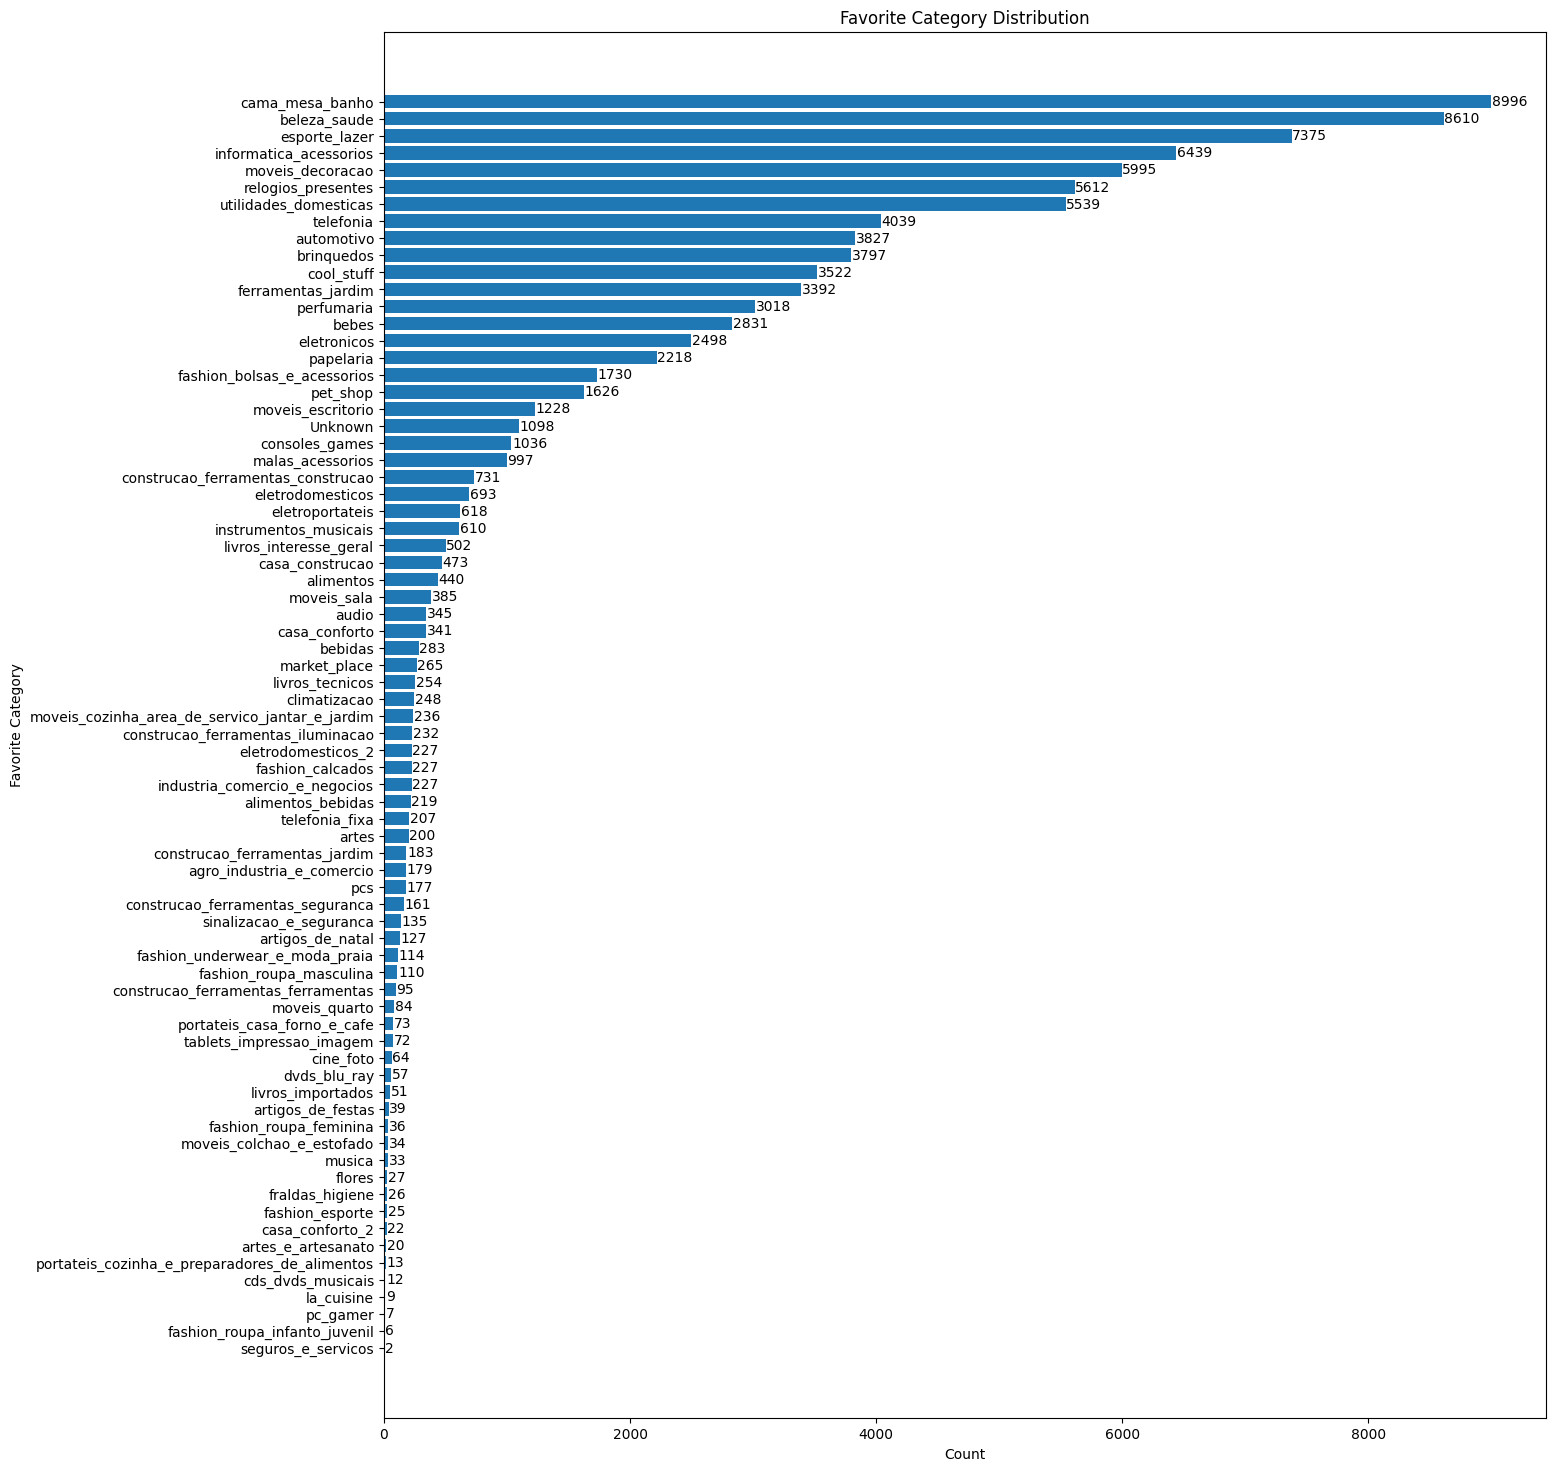

In [77]:
import matplotlib.pyplot as plt

# =========================
# BARPLOT - favorite_category
# =========================

favorite_counts = (
    olist_customers['favorite_category']
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(15, 18))

bars = plt.barh(
    favorite_counts.index,
    favorite_counts.values
)

# Hiện giá trị trên từng bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center'
    )

plt.xlabel('Count')
plt.ylabel('Favorite Category')
plt.title('Favorite Category Distribution')

plt.show()

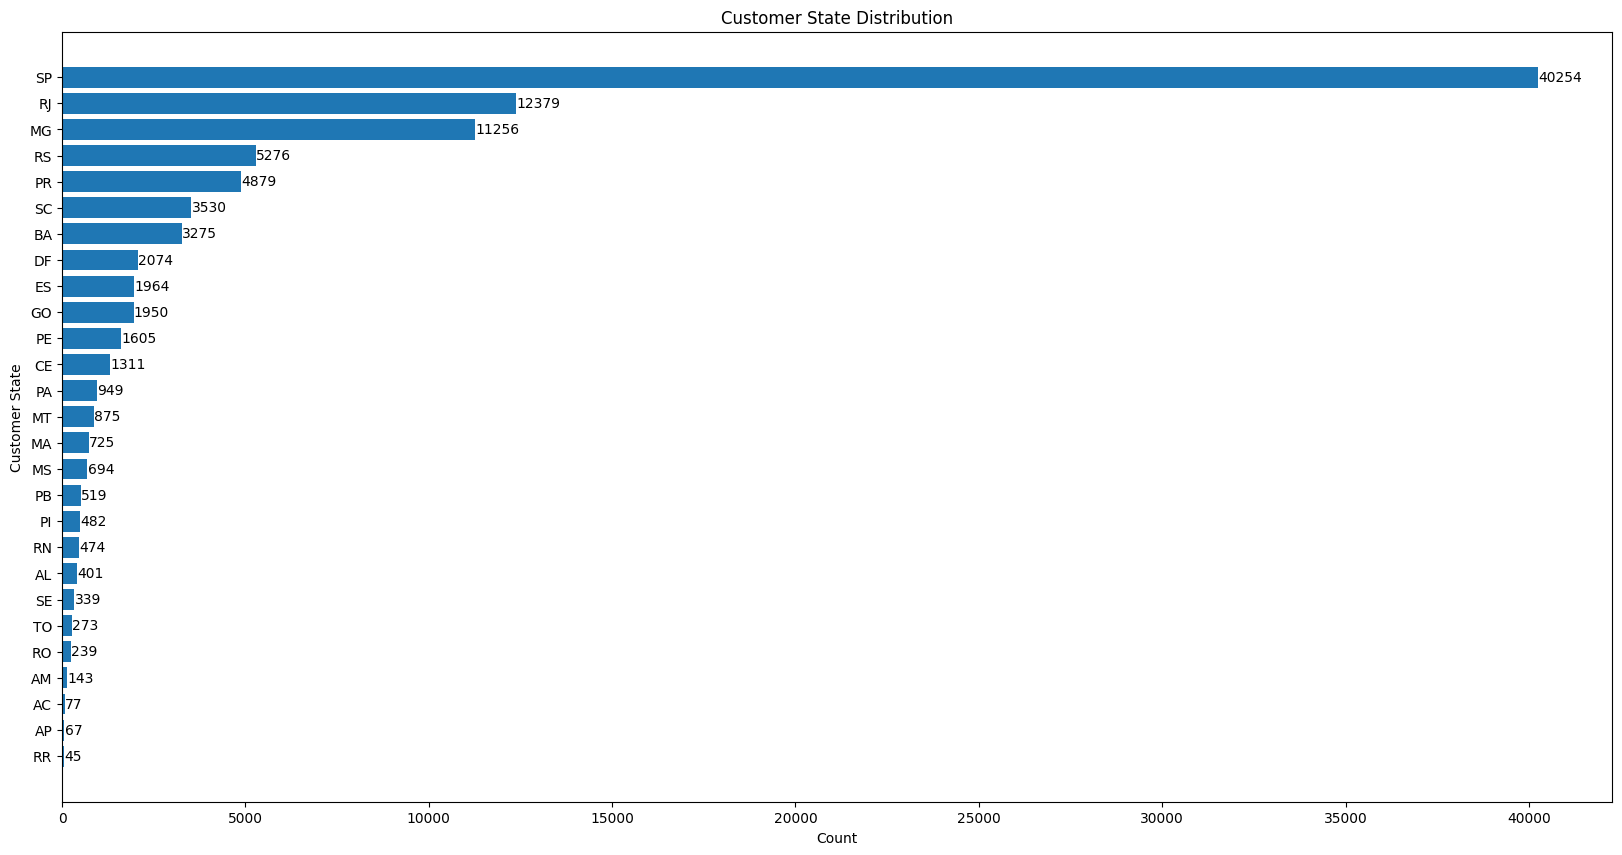

In [82]:
# =========================
# BARPLOT - customer_state
# =========================

state_counts = (
    olist_customers['customer_state']
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(20, 10))

bars = plt.barh(
    state_counts.index,
    state_counts.values
)

# Hiện giá trị trên từng bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 5,
        bar.get_y() + bar.get_height()/2,
        f'{int(width)}',
        va='center'
    )

plt.xlabel('Count')
plt.ylabel('Customer State')
plt.title('Customer State Distribution')

plt.show()

## Numeric

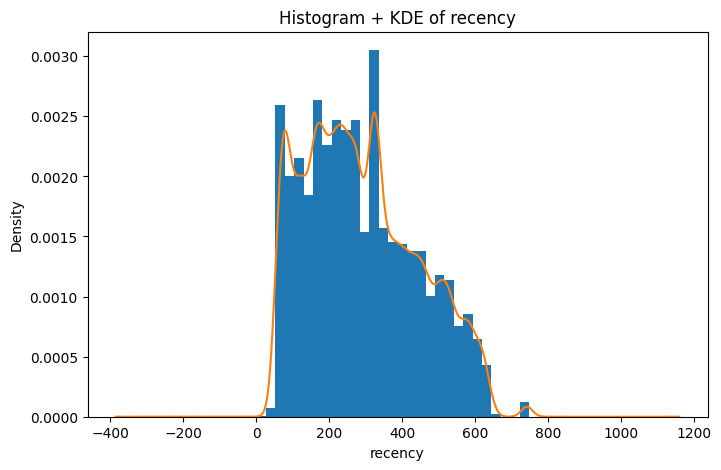

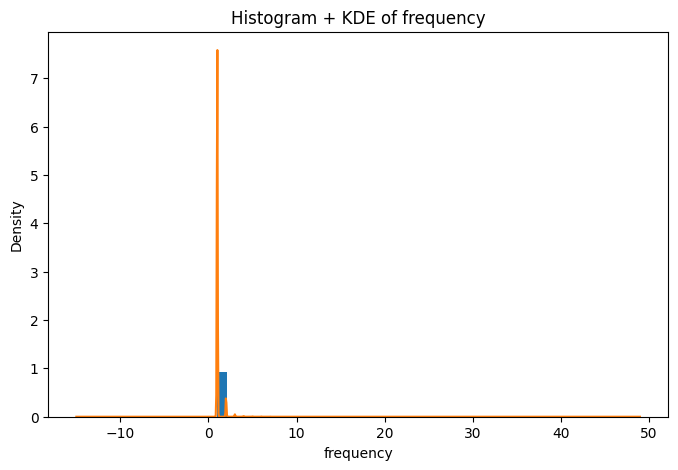

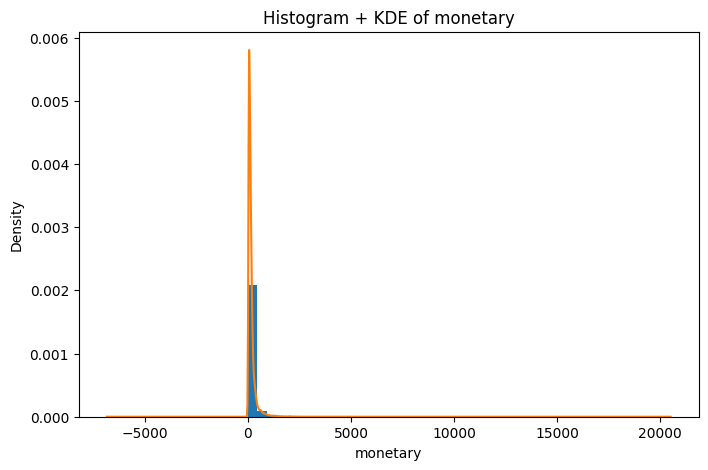

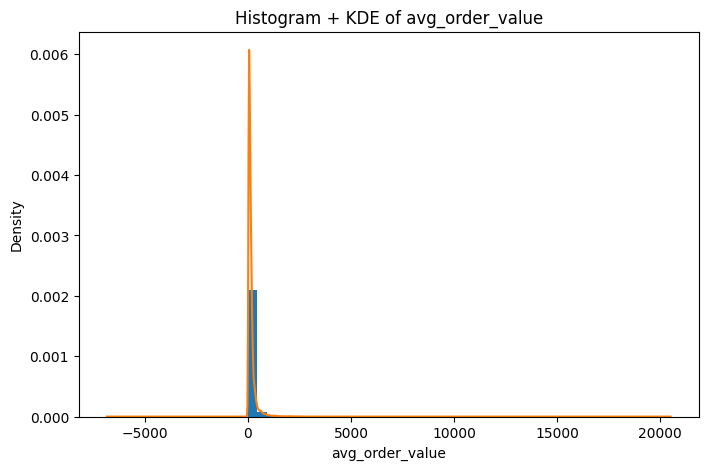

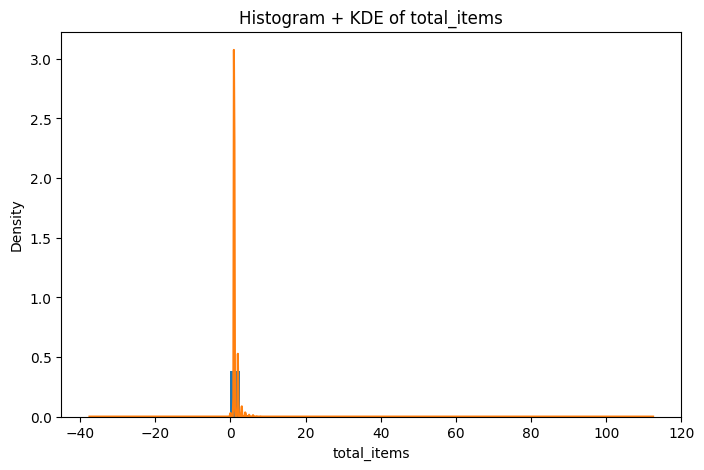

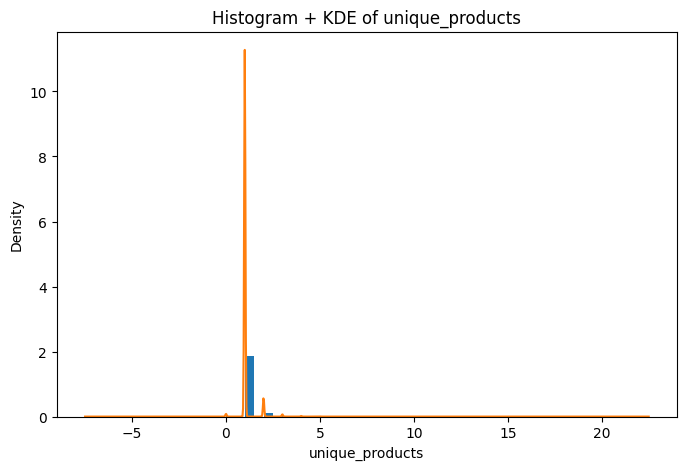

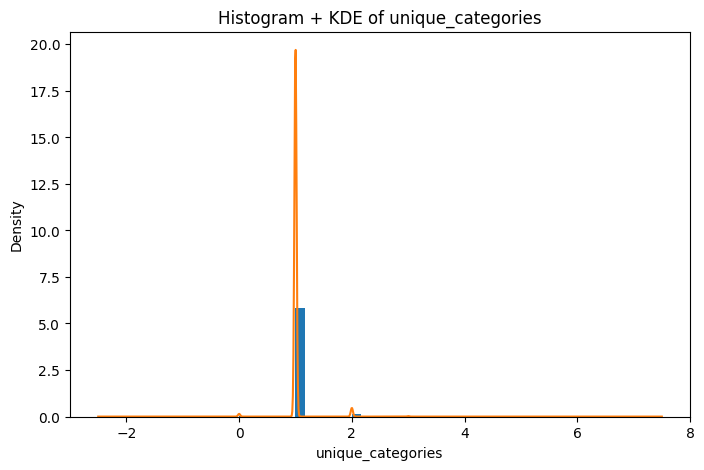

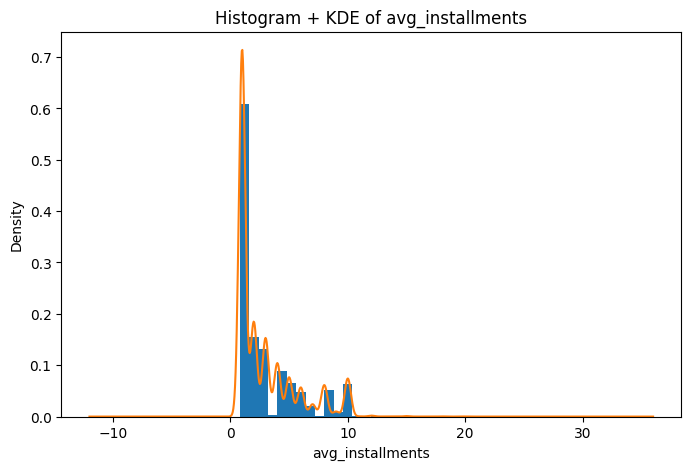

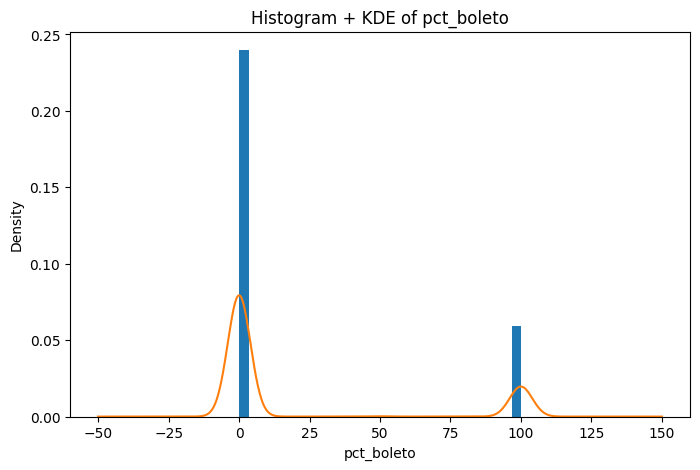

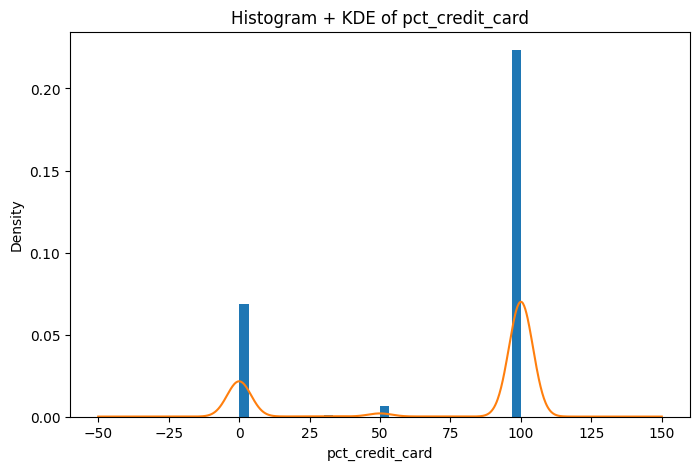

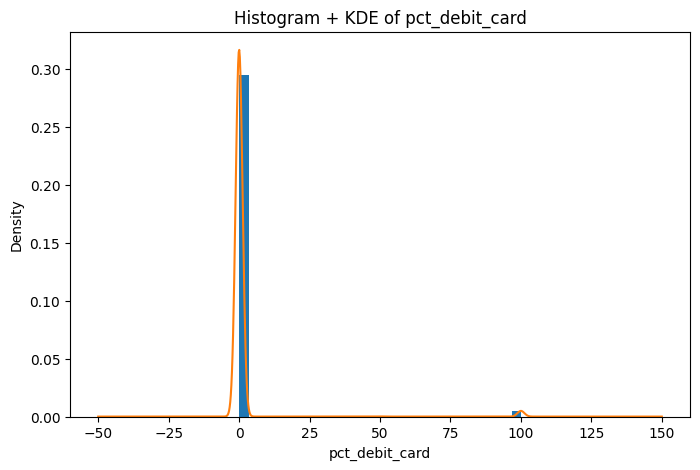

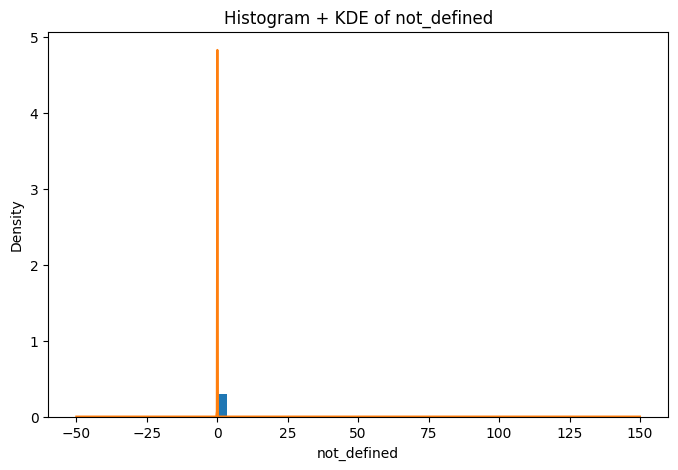

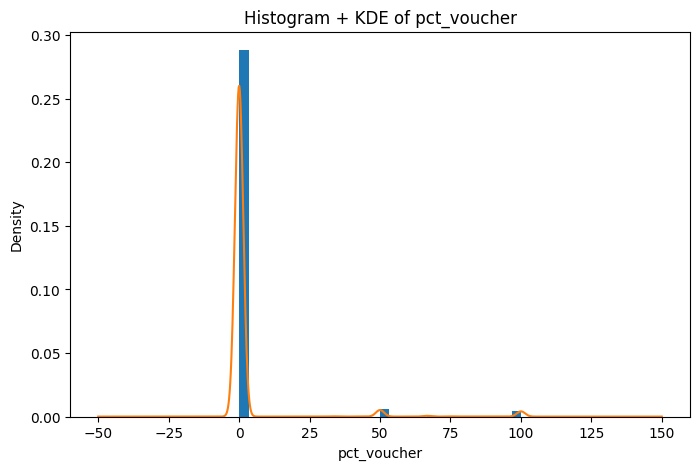

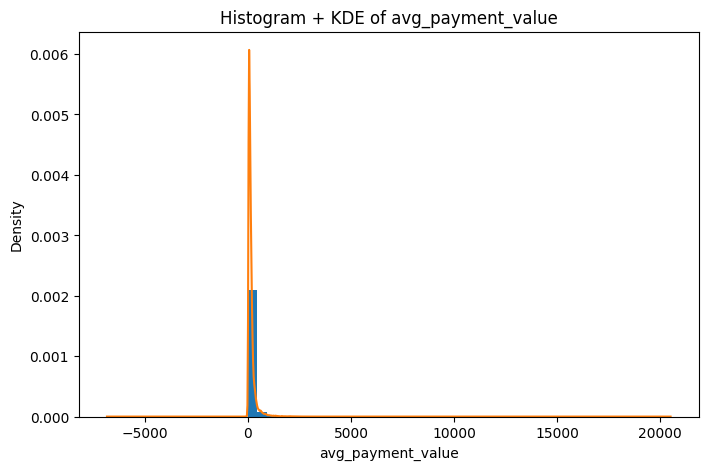

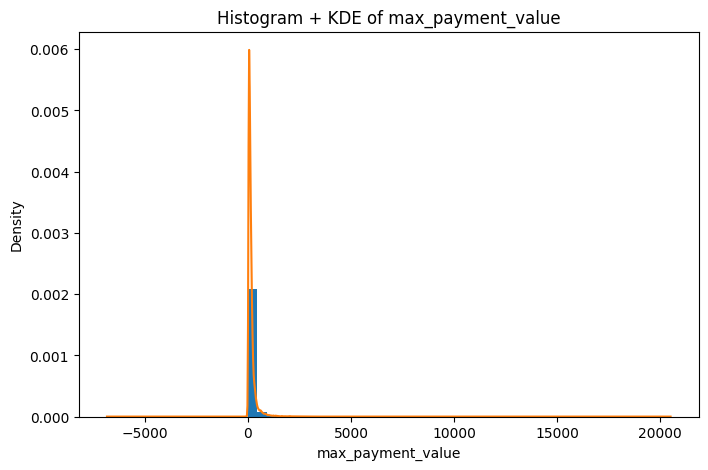

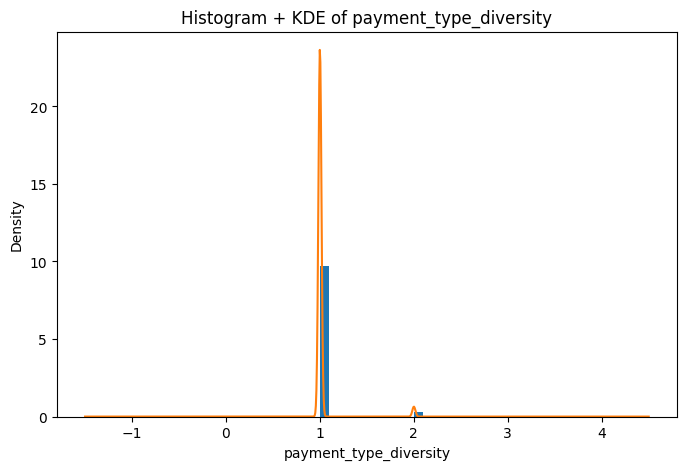

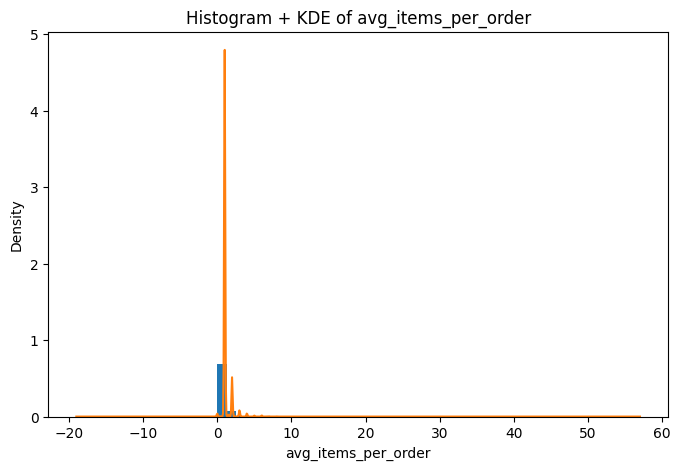

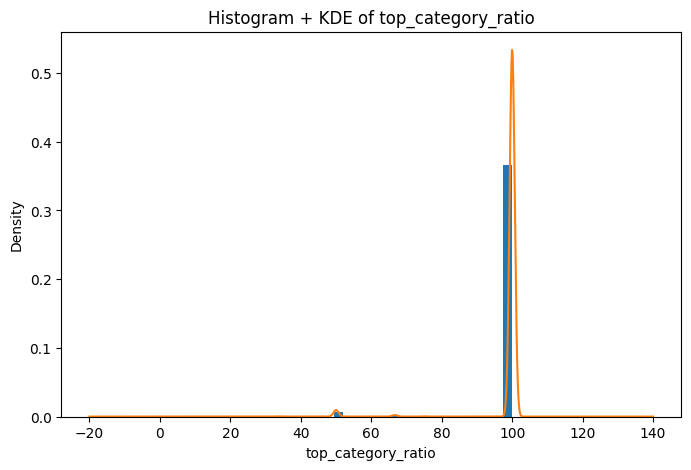

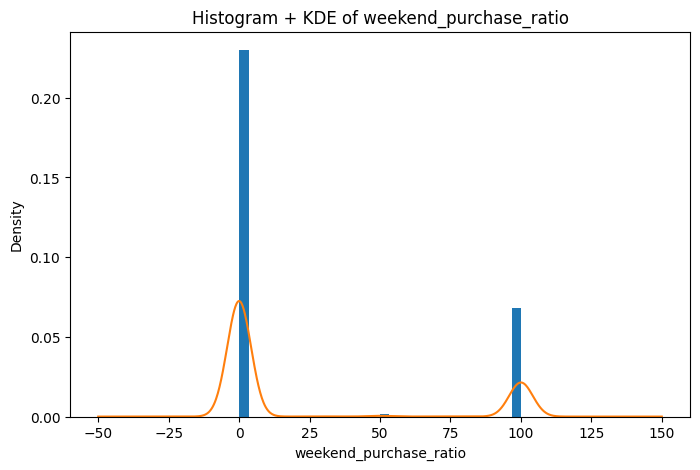

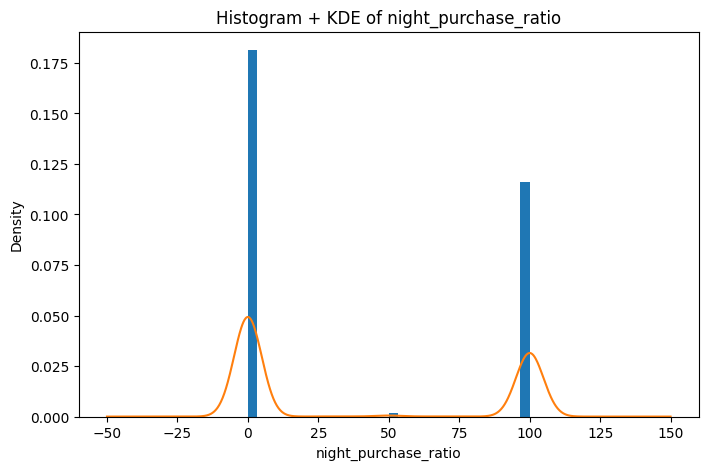

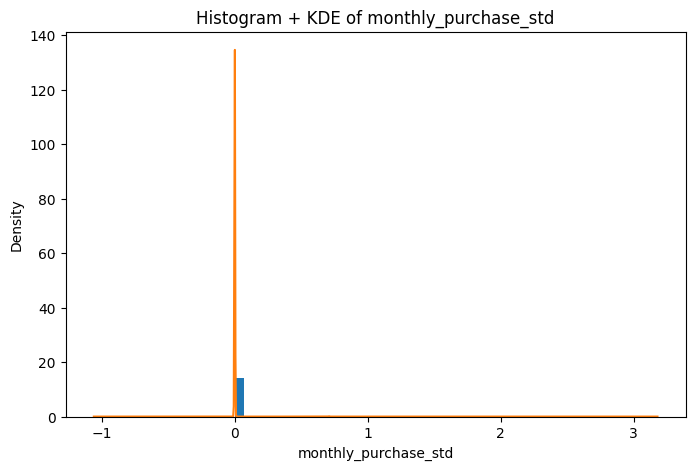

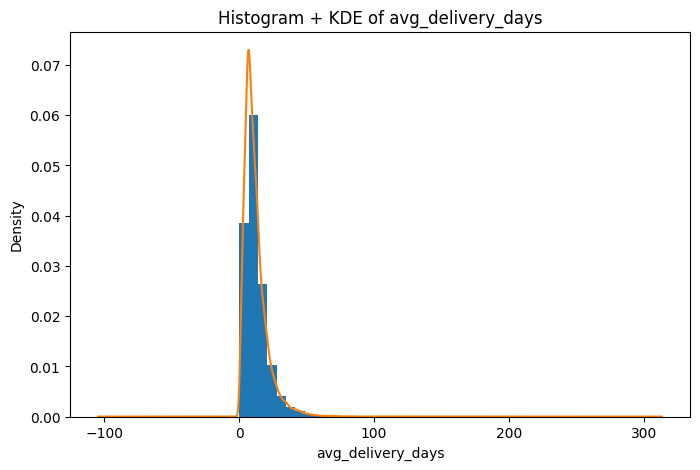

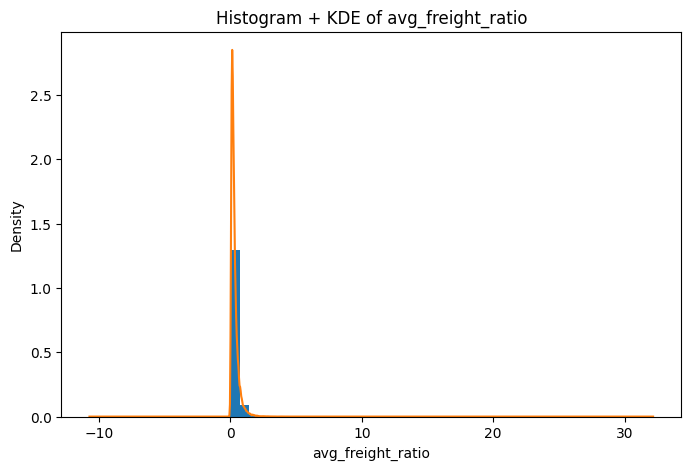

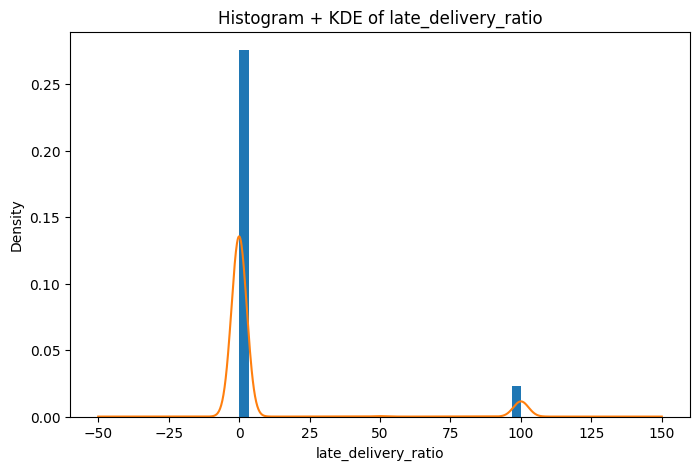

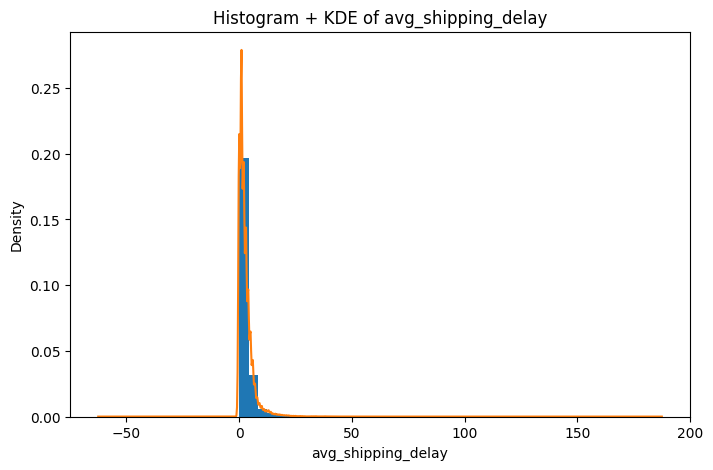

In [84]:
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# Numerical columns
# =========================

numerical_cols = [
    'recency',
    'frequency',
    'monetary',
    'avg_order_value',
    'total_items',
    'unique_products',
    'unique_categories',
    'avg_installments',
    'pct_boleto',
    'pct_credit_card',
    'pct_debit_card',
    'not_defined',
    'pct_voucher',
    'avg_payment_value',
    'max_payment_value',
    'payment_type_diversity',
    'avg_items_per_order',
    'top_category_ratio',
    'weekend_purchase_ratio',
    'night_purchase_ratio',
    'monthly_purchase_std',
    'avg_delivery_days',
    'avg_freight_ratio',
    'late_delivery_ratio',
    'avg_shipping_delay'
]

# =========================
# Histogram + KDE
# =========================

for col in numerical_cols:

    # Drop missing values
    data = olist_customers[col].dropna()

    plt.figure(figsize=(8, 5))

    # Histogram
    plt.hist(
        data,
        bins=30,
        density=True
    )

    # KDE
    data.plot.kde()

    plt.title(f'Histogram + KDE of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')

    plt.show()